# Many Agents and Many Apples - Predicting the Nearest Agent to the Apple using a CNN

In [297]:
# Constants
MLP_D = "mlp_decentralized"
MLP_C = "mlp_centralized"
CNN_D = "cnn_decentralized"
CNN_C = "cnn_centralized"

## Parameters

### CNN and MLP parameters
- MLP_HIDDEN_FEATURES: 128 for cnn 
- MLP_HIDDEN_FEATURES: 89 for mlp decentralized
- MLP_HIDDEN_FEATURES: 97 for mlp centralized

In [ ]:
# Misc
SEED = 42
OUTPUT_FILE = "new_code_results.csv"

# Data Parameters
TOTAL_TRAIN_SAMPLES = 32000
TOTAL_TEST_SAMPLES = 20000
WIDTH = 6
HEIGHT = 6
NUM_AGENTS = 2
S_TARGET = 1
PROBABILITY_AN_APPLE_IS_PICKED = 0.5

# Training Parameters
NUM_EPOCHS = 1
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# Model Parameters
MODEL_TYPE = CNN_D
MLP_HIDDEN_FEATURES = 128 # For mlp model, this is as expected. For CNN, this refers to mlp head of the model only.
MLP_HIDDEN_LAYERS = 2 # Same for this.


### Imports

In [299]:
from pathlib import Path
import pickle
import sys
import os
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNDecentralized, RewardCNNCentralized
from models.reward_network import RewardNetwork
from helpers.controllers import ViewController

### Set the seed

In [300]:
def set_seed(seed_value):
    """Sets the seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        # The two lines below are for ensuring deterministic behavior on GPU
        # but can sometimes have a performance cost.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the seed for your experiment
set_seed(SEED)

# Generate Data

- Self-agent is always at index 0
- With probability p_pick, an apple is picked
- If an apple is picked, pick uniformly at random the agent id picker_id that picks apple and we ensure an apple is at picker_id's position, and no other agent can be in the same cell as an apple. The reward for self-agent is euclid_dist(self-agent's position - picker_id's position) if self-agent does not pick apple, and -1 if it did pick apple.
- If no apple is picked, self-agent get reward of 0


In [301]:
import numpy as np
from tqdm import tqdm
import random

def get_decentralized_reward_when_picked(picker_index, picker_pos, all_agent_positions) -> float:
    """Return the decentralized reward

    Args:
        picker_index: _description_
        picker_pos: _description_
        all_agent_positions: _description_
    """
    if picker_index == 0:  # Self-agent is the picker
        reward = -1.0
    else:
        # Calculate distances from ALL agents to the picker
        distances = np.linalg.norm(all_agent_positions - np.array(picker_pos), axis=1)
        sum_of_distances = np.sum(distances)
        
        if sum_of_distances > 1e-6: # Avoid division by zero
            # Get the self-agent's distance (it's at index 0)
            self_agent_distance = distances[0]
            # Calculate its proportional share of the 2.0 reward pool
            reward = 2 * (self_agent_distance / sum_of_distances)
        else:
            # This case is rare (all agents at the same spot as picker)
            reward = 0.0
    return reward

def generate_probabilistic_apple_distance_dataset(num_samples, width, height, num_agents, s_target, decentralized=True, p_pick=0.5):
    """
    Generates a dataset using the neg_euclidean distance reward logic.
    - If an apple is picked, the picker gets a reward of -1.
    - A total reward of 2.0 is distributed among all other agents, proportional to their
      Euclidean distance from the picker.
    - This function calculates and returns the final reward for the "self-agent" (agent 0).
    
    Args:
        num_samples (int): Number of samples to generate.
        width (int): Width of the grid.
        height (int): Height of the grid.
        num_agents (int): Number of agents in the grid.
        s_target (int): Spawn rate of apples.
        decentralized (bool): If True, the dataset is for decentralized training.
        p_pick (float): Probability that an apple is picked in a scenario.
    """
    dataset = []
    total_cells = width * height
    all_coords_flat = np.arange(total_cells)
    p_cell = (num_agents / total_cells) * s_target if total_cells > 0 else 0

    for _ in tqdm(range(num_samples), desc=f"Generating {num_samples} samples"):
        agents_grid = np.zeros((height, width), dtype=np.int8)
        apples_grid = np.zeros((height, width), dtype=np.int8)

        # 1. Place all agents, ensuring unique positions
        agent_indices_flat = np.random.choice(all_coords_flat, size=num_agents, replace=False)
        agent_rows, agent_cols = np.unravel_index(agent_indices_flat, (height, width))
        agents_grid[agent_rows, agent_cols] = 1
        all_agent_positions = np.column_stack((agent_rows, agent_cols))
        self_agent_pos = tuple(all_agent_positions[0])

        if np.random.rand() < p_pick:
            # --- SCENARIO 1: ONE AGENT PICKS AN APPLE ---
            
            picker_index = np.random.randint(0, num_agents)
            picker_pos = tuple(all_agent_positions[picker_index])
            spawn_mask = np.random.rand(height, width) < p_cell
            spawn_mask[picker_pos] = True
            other_agents_mask = (agents_grid == 1)
            other_agents_mask[picker_pos] = False
            spawn_mask[other_agents_mask] = False
            apples_grid[spawn_mask] = 1
            if decentralized:
                reward = get_decentralized_reward_when_picked(picker_index, picker_pos, all_agent_positions)
            else:
                reward = 1.0

        else:
            spawn_mask = np.random.rand(height, width) < p_cell
            spawn_mask[agents_grid == 1] = False
            apples_grid[spawn_mask] = 1
            reward = 0.0
            
        state = {'agents': agents_grid, 'apples': apples_grid}
        dataset.append({'state': state, 'agent_pos': self_agent_pos, 'reward': reward})
        
    return dataset

# Data

In [302]:
decentralized = True if MODEL_TYPE in [MLP_D, CNN_D] else False
print(f"creating data for {'decentralized' if decentralized else 'centralized'} model")
training_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TRAIN_SAMPLES, 
    WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, decentralized=decentralized, p_pick=PROBABILITY_AN_APPLE_IS_PICKED)
testing_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TEST_SAMPLES, WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, decentralized=decentralized, p_pick=PROBABILITY_AN_APPLE_IS_PICKED)

creating data for centralized model


Generating 20000 samples: 100%|██████████| 20000/20000 [00:00<00:00, 53812.21it/s]


In [303]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_state_counts(data, show_zeros=False, highlight_agent_pos=True, cell_fontsize=12, figsize=None):
    """
    Visualize agents and apples as separate numeric grids.
    - data: one entry like training_data[0]
    - show_zeros: if True, prints '0' for empty cells; otherwise leaves them blank
    - highlight_agent_pos: draws a green border around agent_pos cell
    - cell_fontsize: font size for numbers
    - figsize: tuple (w,h) to override default figure size
    (0,0) is top-left; first coord = row (down), second = column (right).
    """
    state = data['state']
    agents = np.array(state['agents'], dtype=int)
    apples = np.array(state['apples'], dtype=int)
    agent_pos = tuple(int(x) for x in data['agent_pos'])
    reward = float(data['reward'])
    rows, cols = agents.shape

    if figsize is None:
        figsize = (max(6, cols * 0.5 * 2), max(4, rows * 0.5))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    grids = [(agents, "Agents (counts)"), (apples, "Apples (counts)")]

    for ax, (grid, title) in zip(axes, grids):
        # Set coordinate system so (0,0) is top-left
        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(-0.5, rows - 0.5)
        ax.invert_yaxis()  # this makes row 0 appear at top
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))
        ax.set_xticklabels(np.arange(cols))
        ax.set_yticklabels(np.arange(rows))
        ax.set_aspect('equal')
        ax.set_title(title)

        # draw each cell and the number (if nonzero or show_zeros)
        for r in range(rows):
            for c in range(cols):
                # white cell with black border
                rect = Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='white', edgecolor='black', linewidth=0.8)
                ax.add_patch(rect)
                val = int(grid[r, c])
                if show_zeros or val != 0:
                    ax.text(c, r, str(val), ha='center', va='center', fontsize=cell_fontsize)

        # highlight the agent_pos cell (green border)
        if highlight_agent_pos:
            ar, ac = agent_pos
            if 0 <= ar < rows and 0 <= ac < cols:
                hl = Rectangle((ac - 0.5, ar - 0.5), 1, 1, facecolor='none', edgecolor='green', linewidth=2)
                ax.add_patch(hl)

    fig.suptitle(f"Agent position: {agent_pos}    Reward: {reward:.3f}", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig, axes


In [304]:
# for i in range(3):
#     visualize_state_counts(training_data[i])

### Helpers for models

In [305]:
# This is for raw state to input for mlp models
viewController = ViewController(vision=0, new_input=True)
def mlp_processed_state_decentralized(state, agent_pos):
    return viewController.state_to_nn_input(state, agent_pos, None)
def mlp_processed_state_centralized(state):
    return viewController.state_to_nn_input(state, None, None)

def add_model_experience(model, model_type: str, state, agent_pos, reward):
    """Process the state and add the experience to the model's memory."""
    if model_type == MLP_D:
        assert isinstance(model, RewardNetwork), "Model must be an instance of RewardNetwork for MLP types."
        model.add_experience(mlp_processed_state_decentralized(state, agent_pos), reward)
    elif model_type == MLP_C:
        assert isinstance(model, RewardNetwork), "Model must be an instance of RewardNetwork for MLP types."
        model.add_experience(mlp_processed_state_centralized(state), reward)
    elif model_type in [CNN_D, CNN_C]:
        assert isinstance(model, (RewardCNNDecentralized, RewardCNNCentralized)), "Model must be an instance of RewardCNNDecentralized or RewardCNNCentralized for CNN types."
        model.add_experience_from_raw(state, reward, agent_pos=agent_pos)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type}")
    
def train_model(model, model_type: str):
    if model_type in [MLP_D, MLP_C]:
        assert isinstance(model, RewardNetwork), "Model must be an instance of RewardNetwork for MLP types."
        return model.train()
    elif model_type in [CNN_D, CNN_C]:
        assert isinstance(model, (RewardCNNDecentralized, RewardCNNCentralized)), "Model must be an instance of RewardCNNDecentralized or RewardCNNCentralized for CNN types."
        return model.train_batch()
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type}")

def get_model_prediction(model, model_type: str, state, agent_pos) -> float:
    """Get model prediction depending on model type. Note that centralized doesn't use agent_pos.
    """
    if model_type == MLP_D:
        assert isinstance(model, RewardNetwork), "Model must be an instance of RewardNetwork for MLP types."
        processed_state = mlp_processed_state_decentralized(state, agent_pos)
        return model.get_model_reward_prediction(processed_state).item()
    elif model_type == MLP_C:
        assert isinstance(model, RewardNetwork), "Model must be an instance of RewardNetwork for MLP types."
        processed_state = mlp_processed_state_centralized(state)
        return model.get_model_reward_prediction(processed_state).item()
    elif model_type in [CNN_D, CNN_C]:
        assert isinstance(model, (RewardCNNDecentralized, RewardCNNCentralized)), "Model must be an instance of RewardCNNDecentralized or RewardCNNCentralized for CNN types."
        return model.get_model_reward_prediction_from_raw(state, agent_pos=agent_pos).item()
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type}")

In [306]:
def count_parameters(model):
    """Counts the total number of trainable parameters in a PyTorch model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params = -1
# create model
if MODEL_TYPE in [MLP_D, MLP_C]:
    if MODEL_TYPE == MLP_D:
        model = RewardNetwork(WIDTH * HEIGHT * 3, 1, LEARNING_RATE, 0.99, MLP_HIDDEN_FEATURES, 4)
        params = count_parameters(model.model)
    elif MODEL_TYPE == MLP_C:
        model = RewardNetwork(WIDTH * HEIGHT * 2, 1, LEARNING_RATE, 0.99, MLP_HIDDEN_FEATURES, 4)
        params = count_parameters(model.model)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")
else:
    if MODEL_TYPE == CNN_C:
        model = RewardCNNCentralized(WIDTH, HEIGHT, LEARNING_RATE, mlp_hidden_features=MLP_HIDDEN_FEATURES, num_mlp_hidden_layers=MLP_HIDDEN_LAYERS)
        params = count_parameters(model)
    elif MODEL_TYPE == CNN_D:
        model = RewardCNNDecentralized(WIDTH, HEIGHT, LEARNING_RATE, mlp_hidden_features=MLP_HIDDEN_FEATURES, num_mlp_hidden_layers=MLP_HIDDEN_LAYERS)
        params = count_parameters(model)
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")
print(f"Model type: {MODEL_TYPE}, Number of parameters: {params}")

Model type: cnn_centralized, Number of parameters: 25809


In [307]:

for epoch in range(NUM_EPOCHS):
    print(f"--- Starting Epoch {epoch+1}/{NUM_EPOCHS} ---")
    # Shuffle the training data at the beginning of each epoch
    random.shuffle(training_data)

    # Use tqdm for a progress bar over the batches
    progress_bar = tqdm(range(0, TOTAL_TRAIN_SAMPLES, BATCH_SIZE), desc=f"Epoch {epoch+1} Training")

    for i in progress_bar:
        # Get a slice of the data for the current mini-batch
        batch = training_data[i : i + BATCH_SIZE]
        
        # Process each sample in the mini-batch
        for sample in batch:
            state = sample['state']
            agent_pos = sample['agent_pos']
            reward = sample['reward']
            
            # Add experience to the model's internal buffer
            add_model_experience(model, MODEL_TYPE, state, agent_pos, reward)

        # After processing the whole batch, perform one training step
        loss = train_model(model, MODEL_TYPE)
        
        # Update the progress bar with the latest loss
        if loss is not None:
            progress_bar.set_postfix(loss=f"{loss:.4f}")

--- Starting Epoch 1/1 ---


Epoch 1 Training: 100%|██████████| 1000/1000 [00:04<00:00, 207.87it/s, loss=0.0001]


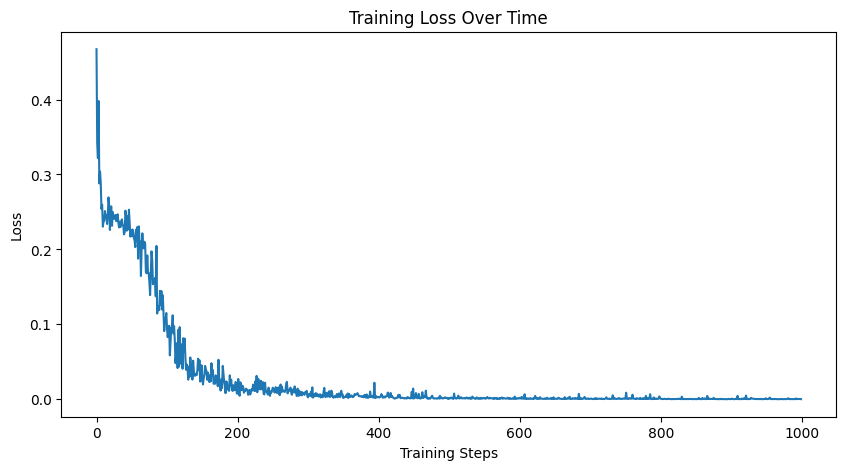

final training loss: 0.00014466099673882127


In [308]:
# PLOT TRAINING LOSS
plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, label='Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

print("final training loss:", model.loss_history[-1])

# TEST MODEL

In [309]:
# --- Step 2: Initialize Variables for Metrics ---
abs_overall_errors = [] # Centralized and Decentralized
abs_errors_when_reward_zero = [] # Centralized and Decentralized

rel_errors_when_reward_bigger_than_0 = []  # Decentralized only
abs_errors_when_reward_minus_one = []  # Decentralized only

abs_errors_when_reward_one = [] # Centralized only

# --- Step 3: The Evaluation Loop ---
print("\n--- Starting Evaluation on Test Set ---")
# No need to shuffle the test set.
for sample in tqdm(testing_data, desc="Evaluating"):
    state = sample['state']
    agent_pos = sample['agent_pos']
    true_reward = sample['reward']
    
    # Get the model's prediction. The .item() is important to get a single float.
    predicted_reward = get_model_prediction(model, MODEL_TYPE, state, agent_pos)
    
    # Calculate the absolute error
    error = abs(predicted_reward - true_reward)
    abs_overall_errors.append(error)
    if true_reward == 0:
        abs_errors_when_reward_zero.append(error)
        
    if MODEL_TYPE in [MLP_C, CNN_C]:  # Centralized
        if true_reward == 1:
            abs_errors_when_reward_one.append(error)
    else:  # Decentralized
        if true_reward > 0:
            rel_errors_when_reward_bigger_than_0.append(abs((error / true_reward)))  # Relative error
        if true_reward == -1:
            abs_errors_when_reward_minus_one.append(error)





--- Starting Evaluation on Test Set ---


Evaluating: 100%|██████████| 20000/20000 [00:12<00:00, 1581.30it/s]


In [310]:
MAPE_positive = (np.mean(rel_errors_when_reward_bigger_than_0) * 100) if rel_errors_when_reward_bigger_than_0 else 0 # Decentralized only
MAE_overall = np.mean(abs_overall_errors) # Centralized and Decentralized
MAE_reward_minus_1 = np.mean(abs_errors_when_reward_minus_one) if abs_errors_when_reward_minus_one else 0 # Decentralized only
MAE_reward_0 = np.mean(abs_errors_when_reward_zero) if abs_errors_when_reward_zero else 0 # Centralized and Decentralized
MAE_reward_one = np.mean(abs_errors_when_reward_one) if abs_errors_when_reward_one else 0 # Centralized only

In [311]:
print("MAE (overall):", MAE_overall)

if MODEL_TYPE in [MLP_C, CNN_C]:  # Centralized
    print("MAE (true reward = 1):", MAE_reward_one)
    print("MAE (true reward = 0):", MAE_reward_0)
else:
    print("MAPE (true reward > 0):", MAPE_positive)
    print("MAE (true reward = -1):", MAE_reward_minus_1)
    print("MAE (true reward = 0):", MAE_reward_0)

MAE (overall): 0.011950730375945568
MAE (true reward = 1): 0.01343633987647633
MAE (true reward = 0): 0.010480491288074496


In [312]:
# if not os.path.exists(OUTPUT_FILE):
#     with open(OUTPUT_FILE, 'w') as f:
#         f.write("PROBABILITY,MAE_overall,MAE_reward_minus_1,MAE_reward_0,MAPE_positive\n")
# with open(OUTPUT_FILE, 'a') as f:
#     f.write(f"{PROBABILITY_AN_APPLE_IS_PICKED},{MAE_overall},{MAE_reward_minus_1},{MAE_reward_0},{MAPE_positive}\n")
# print(f"Results saved to {OUTPUT_FILE}")